# Grid Search: Batch Size x Workers per GPU

Analyzing results from 12 test runs (2026-03-29) sweeping:
- **batch_size**: 16384, 32768, 49152
- **workers_per_gpu**: 1, 2, 3, 4

All runs used M=4096 inducing points, 1 epoch, 1 GPU, on MT sites.

In [1]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

runs_dir = 'runs'
run_tags = [f'032926_{i}' for i in range(1, 13)]

records = []
for tag in run_tags:
    run_path = os.path.join(runs_dir, tag)
    with open(os.path.join(run_path, 'svgp_results.json')) as f:
        results = json.load(f)
    config = results['config']
    
    # Check for OOM in log
    with open(os.path.join(run_path, 'run_log.log')) as f:
        log_text = f.read()
    oom_count = log_text.count('OutOfMemoryError')
    
    # Read fold timings
    timings = pd.read_csv(os.path.join(run_path, 'svgp_fold_timings.csv'))
    
    # workers_per_gpu = n_sites / n_gpus (since n_sites was set to match workers)
    workers_per_gpu = config['n_loso_sites']
    
    for _, row in timings.iterrows():
        records.append({
            'run_tag': tag,
            'batch_size': config['batch_size'],
            'workers_per_gpu': workers_per_gpu,
            'fold': row['fold'],
            'train_time': row['train_time'],
            'ip_selection_time': row['ip_selection_time'],
            'total_fold_time': row['total_fold_time'],
            'n_train': row['n_train'],
            'n_batches_per_epoch': int(np.ceil(row['n_train'] / config['batch_size'])),
            'oom_in_run': oom_count > 0,
            'total_cv_time': results['total_cv_time'],
        })

df = pd.DataFrame(records)
print(f"Loaded {len(df)} fold results from {len(run_tags)} runs")
df.head()

Loaded 17 fold results from 12 runs


,run_tag,batch_size,workers_per_gpu,fold,train_time,ip_selection_time,total_fold_time,n_train,n_batches_per_epoch,oom_in_run,total_cv_time
0,032926_1,16384,1,0,387.161885,74.883772,462.197639,1881145,115,False,466.486513
1,032926_2,16384,2,0,850.034431,101.237634,951.425418,1881145,115,False,956.292486
2,032926_2,16384,2,1,847.980865,99.223282,947.953460,1877397,115,False,956.292486
3,032926_3,16384,3,0,1281.272013,200.056550,1481.712484,1881145,115,False,1489.115533
4,032926_3,16384,3,1,1280.356917,203.298043,1483.965659,1877397,115,False,1489.115533


## Success / OOM Summary

Which batch_size x workers_per_gpu combinations ran without OOM?

In [2]:
# One row per run config
run_summary = df.groupby(['batch_size', 'workers_per_gpu']).agg(
    oom=('oom_in_run', 'first'),
    n_folds_completed=('fold', 'count'),
    total_cv_time=('total_cv_time', 'first'),
).reset_index()

# Pivot: OOM status
oom_pivot = run_summary.pivot(index='batch_size', columns='workers_per_gpu', values='oom')
oom_pivot = oom_pivot.map(lambda x: 'OOM' if x else 'OK')
print("OOM status (batch_size x workers_per_gpu):")
print(oom_pivot)
print()

# Pivot: folds completed
folds_pivot = run_summary.pivot(index='batch_size', columns='workers_per_gpu', values='n_folds_completed')
print("Folds completed:")
print(folds_pivot)

OOM status (batch_size x workers_per_gpu):
workers_per_gpu   1    2    3    4
batch_size                        
16384            OK   OK   OK  OOM
32768            OK  OOM  OOM  OOM
49152            OK  OOM  OOM  OOM

Folds completed:
workers_per_gpu  1  2  3  4
batch_size                 
16384            1  2  3  3
32768            1  1  1  1
49152            1  1  1  1


## Per-fold Training Time

How does training time per fold vary across configurations? Only looking at runs without OOM for clean comparison.

In [3]:
df_ok = df[~df['oom_in_run']].copy()

# Mean training time per fold for each config
train_time_summary = df_ok.groupby(['batch_size', 'workers_per_gpu']).agg(
    mean_train_time=('train_time', 'mean'),
    mean_ip_time=('ip_selection_time', 'mean'),
    mean_total_fold_time=('total_fold_time', 'mean'),
    n_batches=('n_batches_per_epoch', 'first'),
).reset_index()

print("Mean per-fold times (seconds) — OOM-free runs only:")
print(train_time_summary.to_string(index=False, float_format='%.1f'))

# Pivot of mean train time
train_pivot = train_time_summary.pivot(
    index='batch_size', columns='workers_per_gpu', values='mean_train_time'
)
print("\nMean training time per fold (seconds):")
print(train_pivot.round(1))

Mean per-fold times (seconds) — OOM-free runs only:
 batch_size  workers_per_gpu  mean_train_time  mean_ip_time  mean_total_fold_time  n_batches
      16384                1            387.2          74.9                 462.2        115
      16384                2            849.0         100.2                 949.7        115
      16384                3           1280.7         201.2                1482.4        115
      32768                1            349.7          77.5                 427.4         58
      49152                1            342.3          74.3                 416.7         39

Mean training time per fold (seconds):
workers_per_gpu      1      2       3
batch_size                           
16384            387.2  849.0  1280.7
32768            349.7    NaN     NaN
49152            342.3    NaN     NaN


## Total Wall Time vs Throughput

The key question: which config minimizes total wall time for all folds? 
- More workers = slower per fold, but more folds in parallel
- **Throughput** = folds completed / total wall time

In [4]:
# For OOM-free runs: total CV time and throughput
ok_runs = run_summary[~run_summary['oom']].copy()
ok_runs['throughput_folds_per_min'] = ok_runs['n_folds_completed'] / (ok_runs['total_cv_time'] / 60)

print("OOM-free runs — total wall time and throughput:")
print(ok_runs[['batch_size', 'workers_per_gpu', 'n_folds_completed', 
               'total_cv_time', 'throughput_folds_per_min']]
      .to_string(index=False, float_format='%.2f'))

print(f"\nBest throughput:")
best = ok_runs.loc[ok_runs['throughput_folds_per_min'].idxmax()]
print(f"  batch_size={int(best['batch_size'])}, workers_per_gpu={int(best['workers_per_gpu'])}")
print(f"  {best['throughput_folds_per_min']:.2f} folds/min")

OOM-free runs — total wall time and throughput:
 batch_size  workers_per_gpu  n_folds_completed  total_cv_time  throughput_folds_per_min
      16384                1                  1         466.49                      0.13
      16384                2                  2         956.29                      0.13
      16384                3                  3        1489.12                      0.12
      32768                1                  1         431.95                      0.14
      49152                1                  1         421.31                      0.14

Best throughput:
  batch_size=49152, workers_per_gpu=1
  0.14 folds/min


## Visualizations

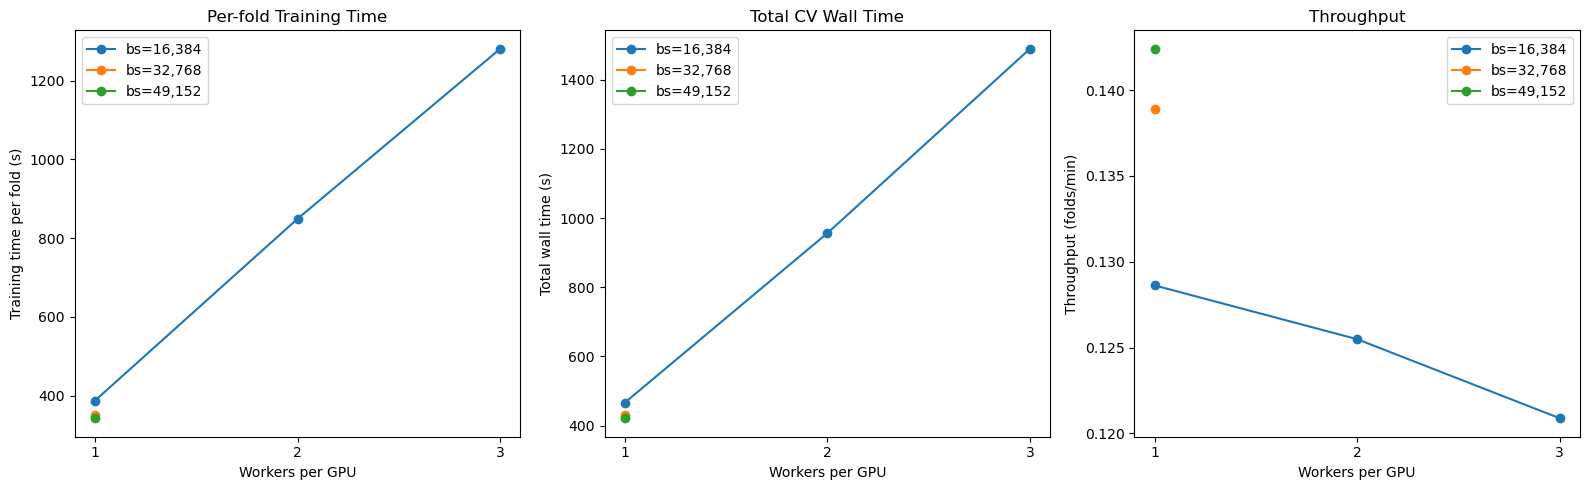

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

batch_sizes = sorted(df_ok['batch_size'].unique())
colors = {16384: '#1f77b4', 32768: '#ff7f0e', 49152: '#2ca02c'}

# Plot 1: Training time per fold
ax = axes[0]
for bs in batch_sizes:
    sub = df_ok[df_ok['batch_size'] == bs].groupby('workers_per_gpu')['train_time'].mean()
    ax.plot(sub.index, sub.values, 'o-', label=f'bs={bs:,}', color=colors[bs])
ax.set_xlabel('Workers per GPU')
ax.set_ylabel('Training time per fold (s)')
ax.set_title('Per-fold Training Time')
ax.legend()
ax.set_xticks([1, 2, 3])

# Plot 2: Total CV wall time
ax = axes[1]
for bs in batch_sizes:
    sub = ok_runs[ok_runs['batch_size'] == bs]
    ax.plot(sub['workers_per_gpu'], sub['total_cv_time'], 'o-', 
            label=f'bs={bs:,}', color=colors[bs])
ax.set_xlabel('Workers per GPU')
ax.set_ylabel('Total wall time (s)')
ax.set_title('Total CV Wall Time')
ax.legend()
ax.set_xticks([1, 2, 3])

# Plot 3: Throughput
ax = axes[2]
for bs in batch_sizes:
    sub = ok_runs[ok_runs['batch_size'] == bs]
    ax.plot(sub['workers_per_gpu'], sub['throughput_folds_per_min'], 'o-', 
            label=f'bs={bs:,}', color=colors[bs])
ax.set_xlabel('Workers per GPU')
ax.set_ylabel('Throughput (folds/min)')
ax.set_title('Throughput')
ax.legend()
ax.set_xticks([1, 2, 3])

plt.tight_layout()
plt.savefig('grid_search_results.png', dpi=150, bbox_inches='tight')
plt.show()

## OOM Heatmap

Visualize which configurations are safe vs OOM.

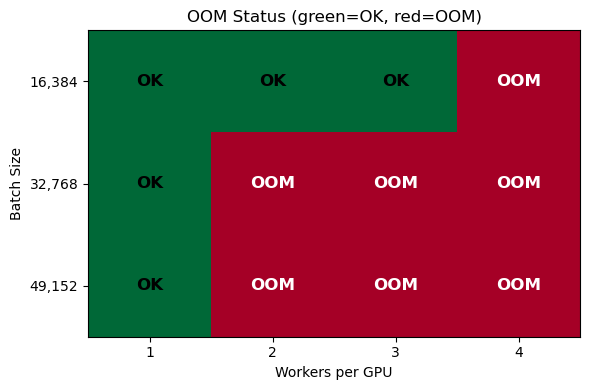

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))

oom_numeric = run_summary.pivot(index='batch_size', columns='workers_per_gpu', values='oom')
oom_numeric = oom_numeric.astype(int)  # 0=OK, 1=OOM

im = ax.imshow(oom_numeric.values, cmap='RdYlGn_r', vmin=0, vmax=1, aspect='auto')

ax.set_xticks(range(len(oom_numeric.columns)))
ax.set_xticklabels(oom_numeric.columns)
ax.set_yticks(range(len(oom_numeric.index)))
ax.set_yticklabels([f'{bs:,}' for bs in oom_numeric.index])
ax.set_xlabel('Workers per GPU')
ax.set_ylabel('Batch Size')
ax.set_title('OOM Status (green=OK, red=OOM)')

for i in range(len(oom_numeric.index)):
    for j in range(len(oom_numeric.columns)):
        val = oom_numeric.iloc[i, j]
        ax.text(j, i, 'OOM' if val else 'OK', ha='center', va='center', 
                fontweight='bold', fontsize=12, color='white' if val else 'black')

plt.tight_layout()
plt.savefig('grid_search_oom.png', dpi=150, bbox_inches='tight')
plt.show()

## Full Run Time Estimates

Estimate total wall time for a production run (20 folds, 5 inducing counts, 50 epochs, 4 GPUs) based on the 1-epoch test results.

In [7]:
# Production run parameters
N_FOLDS = 20
N_GPUS = 4
N_INDUCING_COUNTS = 5  # [256, 512, 1024, 2048, 4096]
AVG_EPOCHS = 30  # reasonable estimate with early stopping (patience=15, max=50)

# Only OOM-free configs
estimates = []
for _, row in ok_runs.iterrows():
    bs = int(row['batch_size'])
    wpg = int(row['workers_per_gpu'])
    
    # Get mean training time per fold per epoch from test (1 epoch)
    fold_times = df_ok[(df_ok['batch_size'] == bs) & (df_ok['workers_per_gpu'] == wpg)]
    mean_train_1epoch = fold_times['train_time'].mean()
    mean_ip_time = fold_times['ip_selection_time'].mean()
    
    # M=4096 is the most expensive; smaller M values are cheaper.
    # Rough scaling: training time scales ~linearly with M for the variational params.
    # Estimate total across inducing counts as ~2x the M=4096 time
    # (256+512+1024+2048 together roughly equal 4096 in cost)
    inducing_multiplier = 2.0
    
    # Per-fold estimate: (train_time_per_epoch * avg_epochs + ip_time) * inducing_multiplier
    est_per_fold = (mean_train_1epoch * AVG_EPOCHS + mean_ip_time) * inducing_multiplier
    
    # Total folds per GPU
    folds_per_gpu = N_FOLDS / N_GPUS  # = 5
    
    # With workers_per_gpu concurrent workers, wall time per GPU:
    # Each worker handles folds_per_gpu/workers_per_gpu folds sequentially
    # But each fold is slower due to GPU contention
    batches_per_gpu = np.ceil(folds_per_gpu / wpg)
    est_wall_per_gpu = batches_per_gpu * est_per_fold
    
    estimates.append({
        'batch_size': bs,
        'workers_per_gpu': wpg,
        'train_time_1epoch_s': mean_train_1epoch,
        'est_per_fold_all_M_min': est_per_fold / 60,
        'est_total_wall_min': est_wall_per_gpu / 60,
        'est_total_wall_hr': est_wall_per_gpu / 3600,
    })

est_df = pd.DataFrame(estimates)
print(f"Estimates assuming {AVG_EPOCHS} epochs avg (early stopping), {N_FOLDS} folds, {N_GPUS} GPUs:")
print(f"{'batch_size':>12} {'wpg':>4} {'train/epoch':>12} {'per_fold':>10} {'total_wall':>12} {'total_hr':>10}")
for _, r in est_df.iterrows():
    print(f"{int(r['batch_size']):>12,} {int(r['workers_per_gpu']):>4} "
          f"{r['train_time_1epoch_s']:>10.0f}s {r['est_per_fold_all_M_min']:>8.1f}min "
          f"{r['est_total_wall_min']:>10.1f}min {r['est_total_wall_hr']:>8.1f}hr")

print(f"\nOptimal config (minimum wall time):")
best_est = est_df.loc[est_df['est_total_wall_hr'].idxmin()]
print(f"  batch_size={int(best_est['batch_size']):,}, workers_per_gpu={int(best_est['workers_per_gpu'])}")
print(f"  Estimated wall time: {best_est['est_total_wall_hr']:.1f} hours")

Estimates assuming 30 epochs avg (early stopping), 20 folds, 4 GPUs:
  batch_size  wpg  train/epoch   per_fold   total_wall   total_hr
      16,384    1        387s    389.7min     1948.3min     32.5hr
      16,384    2        849s    852.3min     2557.0min     42.6hr
      16,384    3       1281s   1287.4min     2574.9min     42.9hr
      32,768    1        350s    352.3min     1761.6min     29.4hr
      49,152    1        342s    344.8min     1723.8min     28.7hr

Optimal config (minimum wall time):
  batch_size=49,152, workers_per_gpu=1
  Estimated wall time: 28.7 hours


## Peak GPU Memory

Using nvidia-smi logs to measure actual peak GPU memory for each run configuration. This determines how close each config is to OOM and how much headroom remains.

In [8]:
# Load nvidia-smi log
gpu_log = pd.read_csv('runs/gpu_log_032926.csv', skipinitialspace=True)
gpu_log.columns = gpu_log.columns.str.strip()
gpu_log['timestamp'] = pd.to_datetime(gpu_log['timestamp'].str.strip())
gpu_log['mem_mib'] = gpu_log['memory.used [MiB]'].astype(str).str.replace(' MiB', '').astype(float)
gpu_log['gpu'] = gpu_log['index'].astype(int)

GPU_TOTAL_MIB = 49140

# Get run time windows from directory modification times
run_windows = []
sorted_tags = sorted(run_tags, key=lambda t: int(t.split('_')[1]))
for i, tag in enumerate(sorted_tags):
    run_path = os.path.join(runs_dir, tag)
    with open(os.path.join(run_path, 'svgp_results.json')) as f:
        r = json.load(f)
    
    # Use run_log.log first line timestamp as start
    with open(os.path.join(run_path, 'run_log.log')) as f:
        first_line = f.readline().strip()
    
    cv_time = r['total_cv_time']
    config = r['config']
    wpg = config['n_loso_sites']
    bs = config['batch_size']
    
    # Approximate start from file modification time minus cv_time
    mtime = os.path.getmtime(os.path.join(run_path, 'svgp_results.json'))
    end_ts = pd.Timestamp.fromtimestamp(mtime)
    start_ts = end_ts - pd.Timedelta(seconds=cv_time)
    
    run_windows.append({
        'run_tag': tag,
        'batch_size': bs,
        'workers_per_gpu': wpg,
        'start': start_ts,
        'end': end_ts,
        'cv_time': cv_time,
    })

run_windows_df = pd.DataFrame(run_windows)
print("Run time windows:")
print(run_windows_df[['run_tag', 'batch_size', 'workers_per_gpu', 'start', 'end']].to_string(index=False))

Run time windows:
  run_tag  batch_size  workers_per_gpu                         start                        end
 032926_1       16384                1 2026-03-29 11:35:06.145125932 2026-03-29 11:42:52.631639
 032926_2       16384                2 2026-03-29 11:42:56.289128182 2026-03-29 11:58:52.581614
 032926_3       16384                3 2026-03-29 11:58:56.269074931 2026-03-29 12:23:45.384608
 032926_4       16384                4 2026-03-29 12:23:49.222419055 2026-03-29 12:49:06.825738
 032926_5       32768                1 2026-03-29 12:49:10.397871879 2026-03-29 12:56:22.347055
 032926_6       32768                2 2026-03-29 12:56:26.031269485 2026-03-29 13:04:03.009668
 032926_7       32768                3 2026-03-29 13:04:06.792574209 2026-03-29 13:11:51.788887
 032926_8       32768                4 2026-03-29 13:11:55.725854118 2026-03-29 13:21:31.520921
 032926_9       49152                1 2026-03-29 13:21:35.034321866 2026-03-29 13:28:36.346236
032926_10       49152 

In [9]:
# Get peak GPU 0 memory during each run's time window
gpu0 = gpu_log[gpu_log['gpu'] == 0].copy()

peak_records = []
for _, rw in run_windows_df.iterrows():
    mask = (gpu0['timestamp'] >= rw['start']) & (gpu0['timestamp'] <= rw['end'])
    sub = gpu0[mask]
    if len(sub) > 0:
        peak = sub['mem_mib'].max()
        mean = sub['mem_mib'].mean()
    else:
        peak = np.nan
        mean = np.nan
    
    peak_records.append({
        'run_tag': rw['run_tag'],
        'batch_size': rw['batch_size'],
        'workers_per_gpu': rw['workers_per_gpu'],
        'peak_mem_mib': peak,
        'peak_mem_gib': peak / 1024,
        'mean_mem_mib': mean,
        'headroom_mib': GPU_TOTAL_MIB - peak,
        'headroom_gib': (GPU_TOTAL_MIB - peak) / 1024,
        'utilization_pct': peak / GPU_TOTAL_MIB * 100,
    })

peak_df = pd.DataFrame(peak_records)

print(f"Peak GPU memory per run (GPU total: {GPU_TOTAL_MIB} MiB = {GPU_TOTAL_MIB/1024:.1f} GiB):")
print(f"{'run_tag':>12} {'bs':>8} {'wpg':>4} {'peak_GiB':>10} {'headroom_GiB':>14} {'util%':>7}")
for _, r in peak_df.iterrows():
    print(f"{r['run_tag']:>12} {int(r['batch_size']):>8,} {int(r['workers_per_gpu']):>4} "
          f"{r['peak_mem_gib']:>8.1f} GiB {r['headroom_gib']:>10.1f} GiB {r['utilization_pct']:>7.1f}%")

Peak GPU memory per run (GPU total: 49140 MiB = 48.0 GiB):
     run_tag       bs  wpg   peak_GiB   headroom_GiB   util%
    032926_1   16,384    1     16.3 GiB       31.7 GiB    34.0%
    032926_2   16,384    2     31.4 GiB       16.6 GiB    65.4%
    032926_3   16,384    3     46.5 GiB        1.5 GiB    96.8%
    032926_4   16,384    4     47.3 GiB        0.7 GiB    98.6%
    032926_5   32,768    1     27.8 GiB       20.2 GiB    57.9%
    032926_6   32,768    2     47.4 GiB        0.6 GiB    98.8%
    032926_7   32,768    3     47.4 GiB        0.6 GiB    98.8%
    032926_8   32,768    4     47.4 GiB        0.6 GiB    98.7%
    032926_9   49,152    1     40.1 GiB        7.8 GiB    83.7%
   032926_10   49,152    2     46.7 GiB        1.2 GiB    97.4%
   032926_11   49,152    3     47.3 GiB        0.7 GiB    98.6%
   032926_12   49,152    4     47.4 GiB        0.6 GiB    98.8%


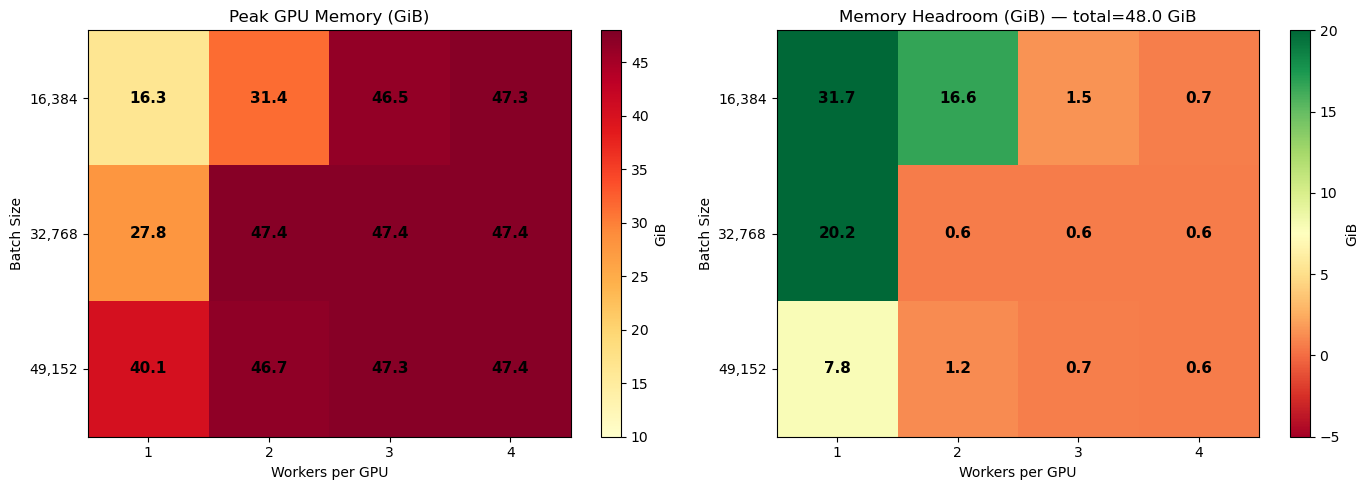


OOM-free configs ranked by headroom:
  bs=16,384 wpg=1 — peak=16.3 GiB, headroom=31.7 GiB (34.0%) [OK]
  bs=32,768 wpg=1 — peak=27.8 GiB, headroom=20.2 GiB (57.9%) [OK]
  bs=16,384 wpg=2 — peak=31.4 GiB, headroom=16.6 GiB (65.4%) [OK]
  bs=49,152 wpg=1 — peak=40.1 GiB, headroom=7.8 GiB (83.7%) [OK]
  bs=16,384 wpg=3 — peak=46.5 GiB, headroom=1.5 GiB (96.8%) [OK]
  bs=49,152 wpg=2 — peak=46.7 GiB, headroom=1.2 GiB (97.4%) [OOM]
  bs=16,384 wpg=4 — peak=47.3 GiB, headroom=0.7 GiB (98.6%) [OOM]
  bs=49,152 wpg=3 — peak=47.3 GiB, headroom=0.7 GiB (98.6%) [OOM]
  bs=32,768 wpg=4 — peak=47.4 GiB, headroom=0.6 GiB (98.7%) [OOM]
  bs=49,152 wpg=4 — peak=47.4 GiB, headroom=0.6 GiB (98.8%) [OOM]
  bs=32,768 wpg=2 — peak=47.4 GiB, headroom=0.6 GiB (98.8%) [OOM]
  bs=32,768 wpg=3 — peak=47.4 GiB, headroom=0.6 GiB (98.8%) [OOM]


In [10]:
# Pivot: peak memory heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Peak memory pivot (GiB)
peak_pivot = peak_df.pivot(index='batch_size', columns='workers_per_gpu', values='peak_mem_gib')

ax = axes[0]
im = ax.imshow(peak_pivot.values, cmap='YlOrRd', aspect='auto', vmin=10, vmax=48)
ax.set_xticks(range(len(peak_pivot.columns)))
ax.set_xticklabels(peak_pivot.columns.astype(int))
ax.set_yticks(range(len(peak_pivot.index)))
ax.set_yticklabels([f'{bs:,}' for bs in peak_pivot.index])
ax.set_xlabel('Workers per GPU')
ax.set_ylabel('Batch Size')
ax.set_title('Peak GPU Memory (GiB)')
for i in range(len(peak_pivot.index)):
    for j in range(len(peak_pivot.columns)):
        val = peak_pivot.iloc[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontweight='bold', fontsize=11)
plt.colorbar(im, ax=ax, label='GiB')

# Headroom pivot (GiB)
headroom_pivot = peak_df.pivot(index='batch_size', columns='workers_per_gpu', values='headroom_gib')

ax = axes[1]
im2 = ax.imshow(headroom_pivot.values, cmap='RdYlGn', aspect='auto', vmin=-5, vmax=20)
ax.set_xticks(range(len(headroom_pivot.columns)))
ax.set_xticklabels(headroom_pivot.columns.astype(int))
ax.set_yticks(range(len(headroom_pivot.index)))
ax.set_yticklabels([f'{bs:,}' for bs in headroom_pivot.index])
ax.set_xlabel('Workers per GPU')
ax.set_ylabel('Batch Size')
ax.set_title(f'Memory Headroom (GiB) — total={GPU_TOTAL_MIB/1024:.1f} GiB')
for i in range(len(headroom_pivot.index)):
    for j in range(len(headroom_pivot.columns)):
        val = headroom_pivot.iloc[i, j]
        if not np.isnan(val):
            label = f'{val:.1f}' if val > 0 else 'OOM'
            ax.text(j, i, label, ha='center', va='center', fontweight='bold', fontsize=11)
plt.colorbar(im2, ax=ax, label='GiB')

plt.tight_layout()
plt.savefig('grid_search_memory.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary for OOM-free configs
print("\nOOM-free configs ranked by headroom:")
ok_peak = peak_df[~peak_df['peak_mem_mib'].isna()].sort_values('headroom_gib', ascending=False)
ok_peak_clean = ok_peak[ok_peak['run_tag'].isin(run_summary[~run_summary['oom']]['run_tag'].values if 'run_tag' in run_summary.columns else ok_runs.merge(run_windows_df, on=['batch_size', 'workers_per_gpu'])['run_tag'].values)]
for _, r in ok_peak.iterrows():
    oom_status = run_summary[(run_summary['batch_size'] == r['batch_size']) & 
                              (run_summary['workers_per_gpu'] == r['workers_per_gpu'])]['oom'].values[0]
    status = 'OOM' if oom_status else 'OK'
    print(f"  bs={int(r['batch_size']):>6,} wpg={int(r['workers_per_gpu'])} — "
          f"peak={r['peak_mem_gib']:.1f} GiB, headroom={r['headroom_gib']:.1f} GiB "
          f"({r['utilization_pct']:.1f}%) [{status}]")